In [0]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Amazon Reviews EDA") \
    .getOrCreate()

In [0]:

reviews_path = "/Volumes/project/data/dataset/Appliances.jsonl"
reviews_df = spark.read.option("multiLine", "false").json(reviews_path)

In [0]:

reviews_df.printSchema()

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [0]:
reviews_df.show()

+----------+------------+------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|      asin|helpful_vote|images|parent_asin|rating|                text|    timestamp|               title|             user_id|verified_purchase|
+----------+------------+------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|B01N0TQ0OH|           0|    []| B01N0TQ0OH|   5.0|work great. use a...|1519317108692|          Work great|AGKHLEW2SOWHNMFQI...|             true|
|B07DD2DMXB|           0|    []| B07DD37QPZ|   5.0|Little on the thi...|1664746863446|   excellent product|AHWWLSPCJMALVHDDV...|             true|
|B082W3Z9YK|           0|    []| B082W3Z9YK|   5.0|Quick delivery, f...|1607225435363|     Happy customer!|AHZIJGKEWRTAEOZ67...|             true|
|B078W2BJY8|           0|    []| B078W2BJY8|   5.0|I wasn't sure whe...|1534104184306|       Amazing value|AFGUPTDFAWO

1) How Big is the Data

In [0]:

reviews_df.count()

2128605

In [0]:
print("Rows:", reviews_df.count())
print("Columns:", len(reviews_df.columns))

Rows: 2128605
Columns: 10


2) Missing Values

In [0]:
from pyspark.sql.functions import col, sum

reviews_df.select([
    sum(col(c).isNull().cast("int")).alias(f"{c}_missing")
    for c in reviews_df.columns
]).show(truncate=False)


+------------+--------------------+--------------+-------------------+--------------+------------+-----------------+-------------+---------------+-------------------------+
|asin_missing|helpful_vote_missing|images_missing|parent_asin_missing|rating_missing|text_missing|timestamp_missing|title_missing|user_id_missing|verified_purchase_missing|
+------------+--------------------+--------------+-------------------+--------------+------------+-----------------+-------------+---------------+-------------------------+
|0           |0                   |0             |0                  |0             |0           |0                |0            |0              |0                        |
+------------+--------------------+--------------+-------------------+--------------+------------+-----------------+-------------+---------------+-------------------------+



In [0]:
reviews_clean = reviews_df.select(
    "rating",
    "title",
    "text",
    "parent_asin",
    "user_id",
    "timestamp",
    "helpful_vote",
    "verified_purchase"
)

In [0]:
from pyspark.sql.functions import col, sum

reviews_clean.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in reviews_clean.columns
]).show()

+------+-----+----+-----------+-------+---------+------------+-----------------+
|rating|title|text|parent_asin|user_id|timestamp|helpful_vote|verified_purchase|
+------+-----+----+-----------+-------+---------+------------+-----------------+
|     0|    0|   0|          0|      0|        0|           0|                0|
+------+-----+----+-----------+-------+---------+------------+-----------------+



In [0]:
print("Rows:", reviews_clean.count())
print("Columns:", len(reviews_clean.columns))

Rows: 2128605
Columns: 8


In [0]:
#3 — Rating distribution
reviews_df.groupBy("rating") \
    .count() \
    .orderBy("rating") \
    .show()


+------+-------+
|rating|  count|
+------+-------+
|   1.0| 250453|
|   2.0|  79664|
|   3.0| 104047|
|   4.0| 208216|
|   5.0|1486225|
+------+-------+



In [0]:
# 4 — Invalid ratings
reviews_df.filter(
    (col("rating") < 1) | (col("rating") > 5)
).count()

0

In [0]:
# 5 Review text Length

from pyspark.sql.functions import length

reviews_df = reviews_df.withColumn(
    "review_length", length("text")
)

reviews_df.select("review_length").describe().show()

+-------+------------------+
|summary|     review_length|
+-------+------------------+
|  count|           2128605|
|   mean|169.51345223749826|
| stddev|279.98141951014395|
|    min|                 0|
|    max|             30004|
+-------+------------------+



In [0]:
## 6 Helpful Votes
reviews_df.select("helpful_vote").describe().show()

+-------+------------------+
|summary|      helpful_vote|
+-------+------------------+
|  count|           2128605|
|   mean|0.9288867591685634|
| stddev|12.526794316769505|
|    min|                 0|
|    max|              5704|
+-------+------------------+



In [0]:
#7 — Verified vs Non-verified
reviews_df.groupBy("verified_purchase") \
    .count() \
    .show()
     

+-----------------+-------+
|verified_purchase|  count|
+-----------------+-------+
|            false|  88541|
|             true|2040064|
+-----------------+-------+



In [0]:
# 8 — Time range of reviews
from pyspark.sql.functions import from_unixtime, min, max

reviews_df.withColumn(
    "review_time",
    from_unixtime(col("timestamp"))
).select(
    min("review_time").alias("min_date"),
    max("review_time").alias("max_date")
).show()

+--------------------+--------------------+
|            min_date|            max_date|
+--------------------+--------------------+
|+32781-05-03 07:0...|+55667-09-18 00:0...|
+--------------------+--------------------+



In [0]:

# correlation between helpfulvotes and rating
reviews_df.stat.corr("helpful_vote", "rating")

-0.028498229072480268

In [0]:
#Total number of rows and duplicate rows
total_count = reviews_df.count()
distinct_count = reviews_df.dropDuplicates().count()

print("Total:", total_count)
print("Duplicates:", total_count - distinct_count)

Total: 2128605
Duplicates: 22656


In [0]:
# Duplicate reviews
from pyspark.sql.functions import count

reviews_df.groupBy("user_id", "asin") \
    .count() \
    .filter("count > 1") \
    .orderBy("count", ascending=False) \
    .show()

+--------------------+----------+-----+
|             user_id|      asin|count|
+--------------------+----------+-----+
|AGBGK5JONOQ7OJEJJ...|B07P3H652K|   11|
|AFB32N5EIVER7YQSE...|B084D61MML|   10|
|AGPD4DZYLFIVX36IS...|B076P93X7V|    9|
|AEIJV4O23Y5XAGGCO...|B08KFL6B5P|    9|
|AENHAAJGKM3ZZZIUS...|B07TGD2245|    9|
|AE3FCVJLMEYKTYBAU...|B07HFPS88T|    8|
|AF6PA4YKGG4WX7H6Y...|B077XWSM7L|    8|
|AHKV2DNQ4WY5VERJ5...|B00DUGIO36|    8|
|AGVAA24XJSIPO6ZLH...|B0052EDYFC|    8|
|AGOELI63KML3B6DUY...|B08QHJYPFW|    8|
|AHH6TK7DOWMNTZSKG...|B078TGXGPX|    8|
|AHKV2DNQ4WY5VERJ5...|B004H3XRDI|    8|
|AGKTDJRORZ2FT3OJ5...|B075M3WDST|    8|
|AE2GBJRPP2FDUICP6...|B008YDSRZK|    8|
|AHZVLQRMSGA3A4MR3...|B0789FR9JK|    8|
|AHZVLQRMSGA3A4MR3...|B078TGXGPX|    8|
|AHEVWFV3FKMI5FNS3...|B01N63XMK4|    8|
|AF2GA6QK5A2F6MJUT...|B00HNEJHT6|    8|
|AEJQXQ6F3I3FHFQLS...|B085ZXG82W|    7|
|AEJRDWRER46NSDQPQ...|B002ZNLJLY|    7|
+--------------------+----------+-----+
only showing top 20 rows


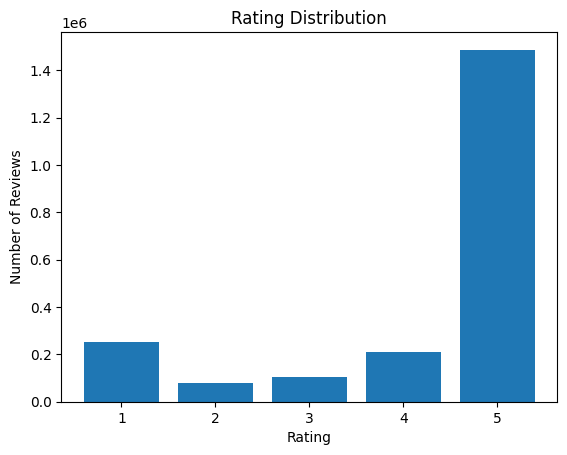

In [0]:
# Rating Distribution (Bar Chart)
# Shows overall customer satisfaction.

rating_df = (
    reviews_df.groupBy("rating")
    .count()
    .orderBy("rating")
    .toPandas()
)

import matplotlib.pyplot as plt

plt.bar(rating_df["rating"], rating_df["count"])
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution")
plt.show()

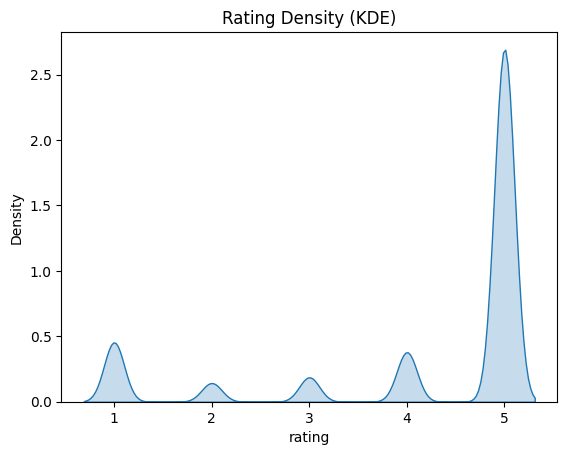

In [0]:
# Rating Density (KDE Plot)
# Smooth view of rating concentration.

rating_sample = reviews_df.select("rating").sample(0.2).toPandas()

import seaborn as sns

sns.kdeplot(rating_sample["rating"], fill=True)
plt.title("Rating Density (KDE)")
plt.show()

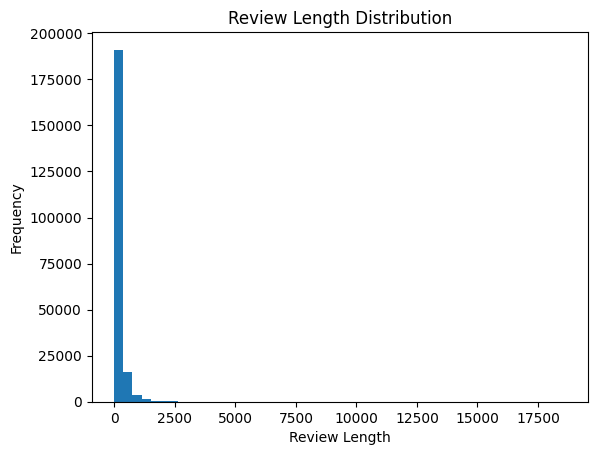

In [0]:
# Review Length Distribution (Histogram)
# Long reviews = complaints / return reasons.

length_df = reviews_df.select("review_length").sample(0.1).toPandas()

plt.hist(length_df["review_length"], bins=50)
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")
plt.show()

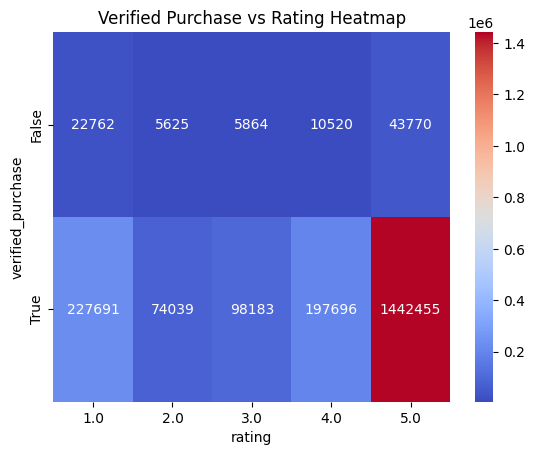

In [0]:

# Heatmap: Rating vs Verified Purchase
heat_df = (
    reviews_df.groupBy("verified_purchase", "rating")
    .count()
    .toPandas()
)

pivot = heat_df.pivot(
    index="verified_purchase",
    columns="rating",
    values="count"
)

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Verified Purchase vs Rating Heatmap")
plt.show()

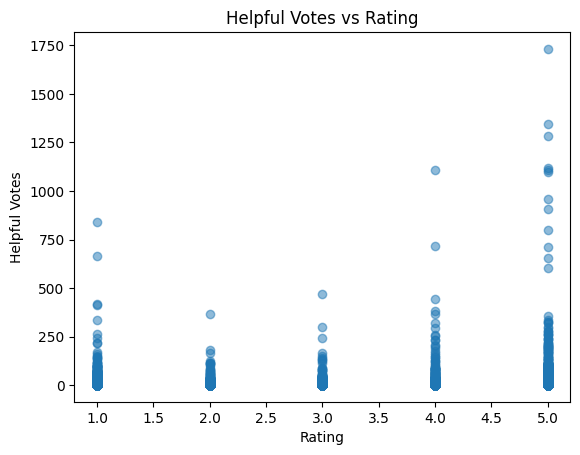

In [0]:
# Helpful Votes vs Rating (Scatter)
# Which reviews influence customers most.

helpful_df = (
    reviews_df
    .filter("helpful_vote > 0")
    .sample(0.1)
    .select("rating", "helpful_vote")
    .toPandas()
)

plt.scatter(helpful_df["rating"], helpful_df["helpful_vote"], alpha=0.5)
plt.xlabel("Rating")
plt.ylabel("Helpful Votes")
plt.title("Helpful Votes vs Rating")
plt.show()

In [0]:
# Sample Dataframe
sample_df = reviews_clean.sample(
    withReplacement=False,
    fraction=0.0025,
    seed=42
)

In [0]:
print("Sample Rows:", sample_df.count())

Sample Rows: 5355


In [0]:
#timestamp column
reviews_clean.select("timestamp").show(10, truncate=False)

+-------------+
|timestamp    |
+-------------+
|1519317108692|
|1664746863446|
|1607225435363|
|1534104184306|
|1620176603754|
|1663078878875|
|1610219023865|
|1480334300000|
|1427130850000|
|1630449561325|
+-------------+
only showing top 10 rows


In [0]:
# DBTITLE 1,Clean up the data
from pyspark.sql.functions import col, from_unixtime, to_timestamp

reviews_clean = reviews_clean.withColumn(
    "timestamp",
    to_timestamp(
        from_unixtime(col("timestamp") / 1000)
    )
)

In [0]:
# timestamp column
reviews_clean.select("timestamp").show(10, truncate=False)

+-------------------+
|timestamp          |
+-------------------+
|2018-02-22 16:31:48|
|2022-10-02 21:41:03|
|2020-12-06 03:30:35|
|2018-08-12 20:03:04|
|2021-05-05 01:03:23|
|2022-09-13 14:21:18|
|2021-01-09 19:03:43|
|2016-11-28 11:58:20|
|2015-03-23 17:14:10|
|2021-08-31 22:39:21|
+-------------------+
only showing top 10 rows


In [0]:
# Create new columns
from pyspark.sql.functions import year, month, dayofmonth

reviews_clean = (
    reviews_clean
    .withColumn("year", year("timestamp"))
    .withColumn("month", month("timestamp"))
    .withColumn("day", dayofmonth("timestamp"))
)

In [0]:
# Check
reviews_clean.select(
    "timestamp",
    "year",
    "month"
).show(5)

+-------------------+----+-----+
|          timestamp|year|month|
+-------------------+----+-----+
|2018-02-22 16:31:48|2018|    2|
|2022-10-02 21:41:03|2022|   10|
|2020-12-06 03:30:35|2020|   12|
|2018-08-12 20:03:04|2018|    8|
|2021-05-05 01:03:23|2021|    5|
+-------------------+----+-----+
only showing top 5 rows


In [0]:
joined_df = reviews_clean.join(
    metadata_clean,
    on="parent_asin",
    how="inner"
)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-6920187033598974>, line 1
----> 1 joined_df = reviews_clean.join(
      2     metadata_clean,
      3     on="parent_asin",
      4     how="inner"
      5 )

NameError: name 'reviews_clean' is not defined

In [0]:
# Sample Pandas DataFrame
sample_pd = sample_df.toPandas()

In [0]:
# Sentiment
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

sample_pd["sentiment"] = sample_pd["rating"].apply(sentiment_label)

In [0]:
sample_pd["sentiment"].value_counts()

In [0]:
# Shape
sample_pd.shape

# Missing values
sample_pd.isnull().sum()

# Rating distribution
sample_pd["rating"].value_counts()

# Sentiment distribution
sample_pd["sentiment"].value_counts()

In [0]:
#Text Preprocessing
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        word
        for word in words
        if word not in ENGLISH_STOP_WORDS
    ]

    return " ".join(words)

sample_pd["clean_text"] = sample_pd["text"].apply(preprocess_text)

In [0]:
sample_pd[["text", "clean_text"]].head()

In [0]:
#Train_test_split
from sklearn.model_selection import train_test_split

X = sample_pd["clean_text"]

y = sample_pd["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [0]:
#TF-IDF Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [0]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

In [0]:
#Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(
    X_test_tfidf
)

In [0]:
#metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(
    y_test,
    nb_pred
)

precision = precision_score(
    y_test,
    nb_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    nb_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    nb_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

In [0]:
#classification report
print(
    classification_report(
        y_test,
        nb_pred
    )
)

In [0]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    nb_pred
)

print(cm)

In [0]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

In [0]:
#Hyperparameter Tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha":[
        0.01,
        0.1,
        0.5,
        1.0,
        2.0
    ]
}

grid_search = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(
    X_train_tfidf,
    y_train
)

In [0]:
print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    "Best Score:",
    grid_search.best_score_
)

In [0]:
#Best Model Prediction
best_nb = grid_search.best_estimator_

best_pred = best_nb.predict(
    X_test_tfidf
)

In [0]:
print(
    classification_report(
        y_test,
        best_pred
    )
)

print(
    confusion_matrix(
        y_test,
        best_pred
    )
)

In [0]:
#Results
results = {
    "Model":["Multinomial Naive Bayes"],
    "Accuracy":[accuracy_score(y_test,best_pred)],
    "Precision":[precision_score(y_test,best_pred,average="weighted")],
    "Recall":[recall_score(y_test,best_pred,average="weighted")],
    "F1":[f1_score(y_test,best_pred,average="weighted")]
}

import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)